<a href="https://colab.research.google.com/github/turtul17/tyttt/blob/main/Image_Segmentation_%26_Object_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Upload an image


Saving person.jpeg to person (3).jpeg

Output 1: Original Image


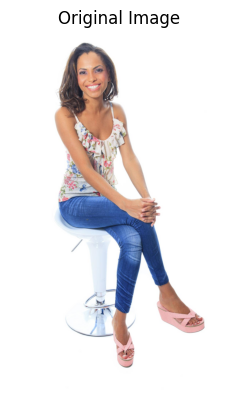


Output 2: Global Thresholding


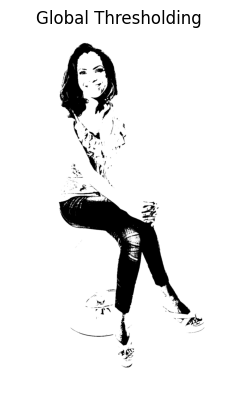


Output 3: Adaptive Thresholding


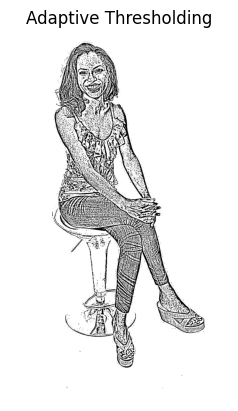


Output 4: K-Means Clustering


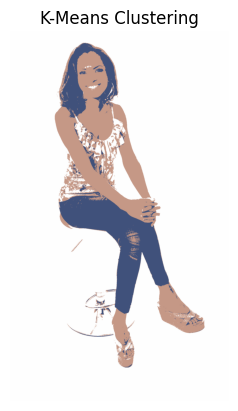


Output 5: Region Growing


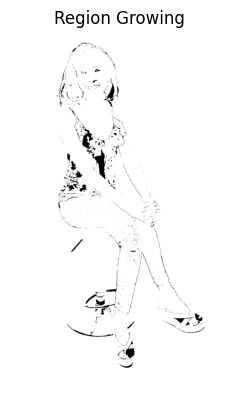


Output 6: Face Detection


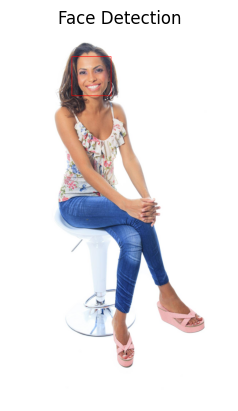


Output 7: HOG Detection


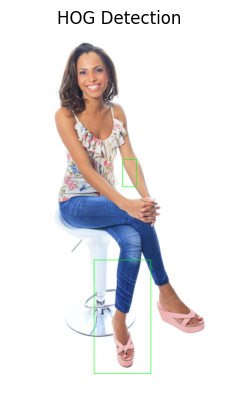

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

print("Upload an image")
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

print("\nOutput 1: Original Image")
plt.imshow(img)
plt.title("Original Image")
plt.axis('off')
plt.show()

_, th1 = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

print("\nOutput 2: Global Thresholding")
plt.imshow(th1, cmap='gray')
plt.title("Global Thresholding")
plt.axis('off')
plt.show()

th2 = cv2.adaptiveThreshold(gray, 255,
                            cv2.ADAPTIVE_THRESH_MEAN_C,
                            cv2.THRESH_BINARY, 11, 2)

print("\nOutput 3: Adaptive Thresholding")
plt.imshow(th2, cmap='gray')
plt.title("Adaptive Thresholding")
plt.axis('off')
plt.show()

Z = img.reshape((-1, 3))
Z = np.float32(Z)

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
K = 3

_, label, center = cv2.kmeans(Z, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

center = np.uint8(center)
res = center[label.flatten()]
clustered = res.reshape((img.shape))

print("\nOutput 4: K-Means Clustering")
plt.imshow(clustered)
plt.title("K-Means Clustering")
plt.axis('off')
plt.show()

seed = (100, 100)
threshold = 10

region = np.zeros_like(gray)
visited = np.zeros_like(gray)

stack = [seed]

while stack:
    x, y = stack.pop()
    if visited[x, y] == 1:
        continue
    visited[x, y] = 1
    region[x, y] = 255

    for dx in [-1, 0, 1]:
        for dy in [-1, 0, 1]:
            nx, ny = x + dx, y + dy
            if 0 <= nx < gray.shape[0] and 0 <= ny < gray.shape[1]:
                if abs(int(gray[nx, ny]) - int(gray[x, y])) < threshold:
                    stack.append((nx, ny))

print("\nOutput 5: Region Growing")
plt.imshow(region, cmap='gray')
plt.title("Region Growing")
plt.axis('off')
plt.show()

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
)

faces = face_cascade.detectMultiScale(gray, 1.3, 5)

img_face = img.copy()

for (x, y, w, h) in faces:
    cv2.rectangle(img_face, (x, y), (x + w, y + h), (255, 0, 0), 2)

print("\nOutput 6: Face Detection")
plt.imshow(img_face)
plt.title("Face Detection")
plt.axis('off')
plt.show()

hog = cv2.HOGDescriptor()
hog.setSVMDetector(cv2.HOGDescriptor_getDefaultPeopleDetector())

boxes, _ = hog.detectMultiScale(img)

img_hog = img.copy()

for (x, y, w, h) in boxes:
    cv2.rectangle(img_hog, (x, y), (x + w, y + h), (0, 255, 0), 2)

print("\nOutput 7: HOG Detection")
plt.imshow(img_hog)
plt.title("HOG Detection")
plt.axis('off')
plt.show()